# 合成データ(data.mat)の可視化

`run/make_synthetic_data.py` で生成した stand-in データが物理的に妥当か
(D(x,y) が想定した関数形になっているか、C(x,y,t) が時間とともに拡散して
滑らかになっていくか)を、実際の学習を回す前に目視で確認する。

背景・データの由来は `src/synthetic_data.py` のdocstring、および
本物の `data.mat` が失われている経緯は `docs/20260907.md` 以降の
やり取りを参照。

In [6]:
import os

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from scipy.interpolate import griddata

In [7]:
# 確認したいケースとデータの場所
CASE = 1
DATA_DIR = os.path.expanduser("~/server/PINNs-LLC/data")
data_path = os.path.join(DATA_DIR, f"case{CASE}", "data.mat")
data_path

'/Users/nkn4ryu/server/PINNs-LLC/data/case1/data.mat'

In [8]:
data = scipy.io.loadmat(data_path)

Diff_star = data["Diff_star"]  # N x T (time-invariant, tiled across T)
C_star = data["C_star"]        # N x T
t_star = data["t"].T           # T x 1
X_star = data["X_star"]        # N x 2

print("X_star", X_star.shape)
print("C_star", C_star.shape)
print("Diff_star", Diff_star.shape)
print("t_star", t_star.shape, "range", t_star.min(), t_star.max())
print("C range", C_star.min(), C_star.max())
print("D range", Diff_star.min(), Diff_star.max())

X_star (16384, 2)
C_star (16384, 100)
Diff_star (16384, 100)
t_star (100, 1) range 0.0 1.0
C range 1.0848552640429378e-17 0.9975810505410718
D range 0.05 0.09999689999379999


In [9]:
# プロット用の規則格子(元のnotebookと同じgriddata方式。元データの解像度に依存しない)
lb = X_star.min(0)
ub = X_star.max(0)
nn = 200
x = np.linspace(lb[0], ub[0], nn)
y = np.linspace(lb[1], ub[1], nn)
X, Y = np.meshgrid(x, y)

## 拡散係数 D(x,y)

`src/synthetic_data.py` の `d_true(case, x, y)` の関数形と一致しているはず。

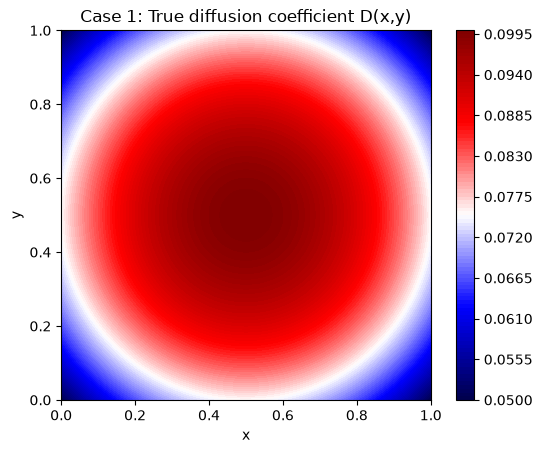

In [10]:
DIFF_grid = griddata(X_star, Diff_star[:, 0].flatten(), (X, Y), method="cubic")

fig, ax = plt.subplots()
cs = ax.contourf(X, Y, DIFF_grid, levels=100, cmap="seismic")
ax.set_title(f"Case {CASE}: True diffusion coefficient D(x,y)")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(cs)
plt.show()

## 濃度場 C(x,y,t) の時間発展

中心のガウス分布(初期条件)が、D(x,y)に従って非一様に拡散していく様子。
境界は no-flux としているので、濃度の総量はほぼ保存されるはず。

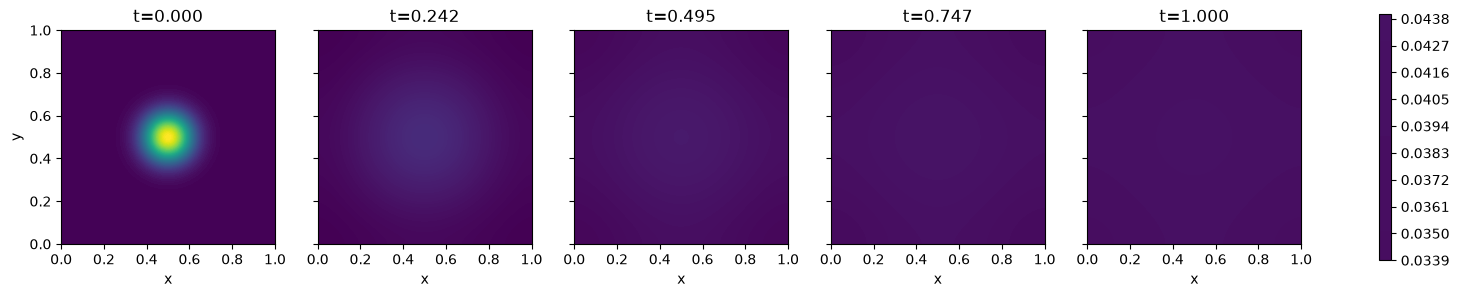

In [11]:
T = C_star.shape[1]
snapshot_idx = np.linspace(0, T - 1, 5).astype(int)

fig, axes = plt.subplots(1, len(snapshot_idx), figsize=(4 * len(snapshot_idx), 4), sharey=True)
vmin, vmax = C_star.min(), C_star.max()
for ax, idx in zip(axes, snapshot_idx):
    C_grid = griddata(X_star, C_star[:, idx].flatten(), (X, Y), method="cubic")
    cs = ax.contourf(X, Y, C_grid, levels=100, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"t={t_star[idx, 0]:.3f}")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(cs, ax=axes, shrink=0.8)
plt.show()

## 総量(質量)の保存チェック

no-flux境界条件が正しく効いていれば、$\int C\,dx\,dy$ はほぼ一定のはず
(格子点が非一様サンプリングのため単純平均で近似)。

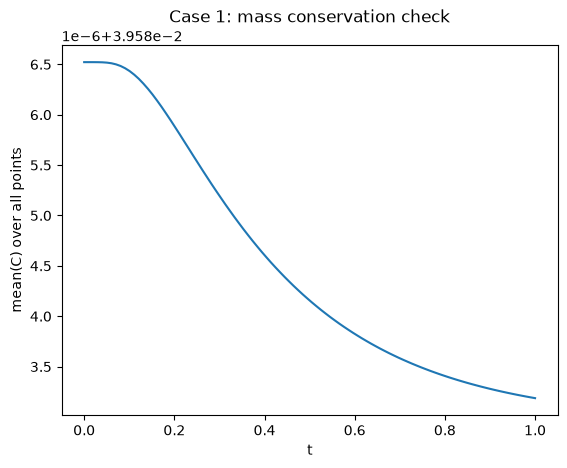

In [12]:
mass_proxy = C_star.mean(axis=0)  # N点の平均 (一様格子なら合計に比例)

plt.figure()
plt.plot(t_star[:, 0], mass_proxy)
plt.xlabel("t")
plt.ylabel("mean(C) over all points")
plt.title(f"Case {CASE}: mass conservation check")
plt.show()